In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA'
)

Downloading bucket files: 43695338 / 43695338 complete

Downloading bytes: 43695338 / 43695338 complete

In [3]:
ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64

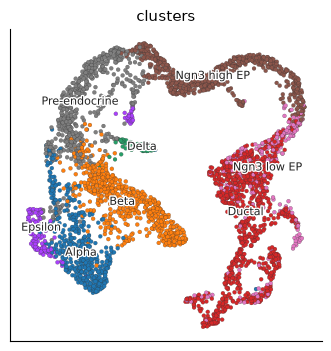

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)

In [6]:
{
    "pseudotime_key": pseudotime.pseudotime_key,
    "validity_key": pseudotime.validity_key,
    "valid cells": int(ds.cells.fetch_all(pseudotime.validity_key).sum()),
}

{'pseudotime_key': 'RNA_pseudotime',
 'validity_key': 'RNA_pseudotime__valid',
 'valid cells': 3696}

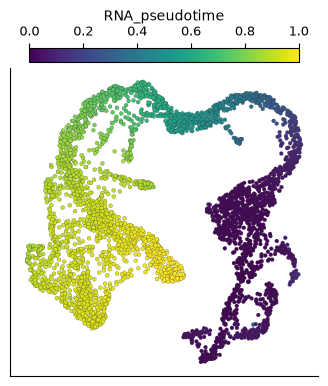

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
    subset_by=pseudotime.validity_key,
)

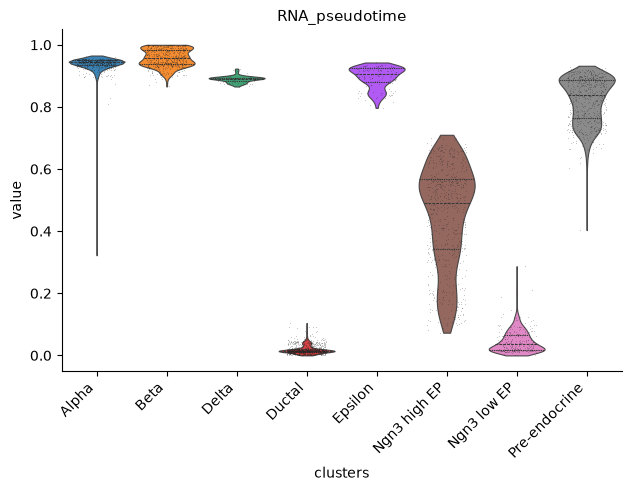

In [8]:
ds.plots.distribution(
    keys=pseudotime.pseudotime_key,
    group_by='clusters',
    subset_by=pseudotime.validity_key,
    kind='violin',
)

In [9]:
markers = ds.run_pseudotime_marker_search(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)

Finding correlated features: 1 / 1 complete

In [10]:
markers.table[["p_value", "p_value_adjusted"]].isna().sum()

p_value             0
p_value_adjusted    0
dtype: int64

In [11]:
markers.table[["p_value", "p_value_adjusted"]].notna().sum()

p_value             12682
p_value_adjusted    12682
dtype: int64

In [12]:
tested = markers.table.loc[
    markers.table["p_value_adjusted"].notna(),
    ["feature_name", "r_value", "p_value_adjusted"],
]
(
    tested.loc[tested["r_value"] > 0]
    .sort_values("r_value", ascending=False)
    .head(10)
)

,feature_name,r_value,p_value_adjusted
6902,Gnas,0.746087,0.0
10923,Cpe,0.739462,0.0
9986,Aplp1,0.716134,0.0
1435,Fam183b,0.679348,0.0
11752,Hmgn3,0.635711,0.0
12473,Pcsk1n,0.633742,0.0
12400,Bex2,0.620820,0.0
957,Rap1b,0.611709,0.0
2847,Scgn,0.609422,0.0
12482,Tspan7,0.598024,0.0


In [13]:
(
    tested.loc[tested["r_value"] < 0]
    .sort_values("r_value", ascending=True)
    .head(10)
)

,feature_name,r_value,p_value_adjusted
11497,Rpl13,-0.828517,0.0
10436,Rps19,-0.821364,0.0
8979,Spp1,-0.821112,0.0
7747,Rps8,-0.817098,0.0
9443,Rpl32,-0.793551,0.0
12367,Rps4x,-0.793366,0.0
177,Dbi,-0.788328,0.0
6533,Rpl12,-0.769530,0.0
4948,Rps2,-0.756031,0.0
4993,Rpl10a,-0.753413,0.0


In [14]:
checkpoint_genes = ["Spp1", "Cpe"]
checkpoint = (
    markers.table.set_index("feature_name")
    .loc[checkpoint_genes, ["r_value", "p_value_adjusted"]]
)
checkpoint

,r_value,p_value_adjusted
feature_name,,
Spp1,-0.821112,0.0
Cpe,0.739462,0.0


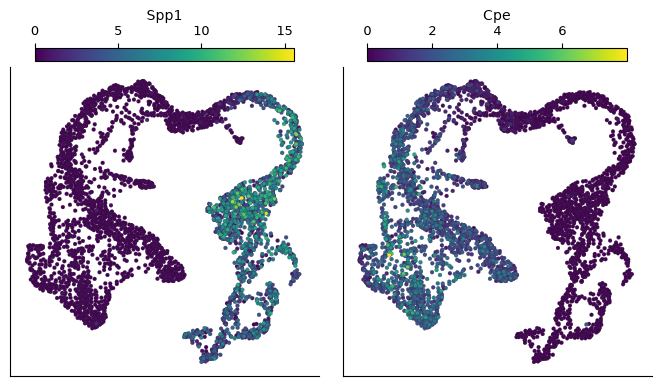

In [15]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=checkpoint_genes,
    n_columns=2,
    sort_values=True,
)

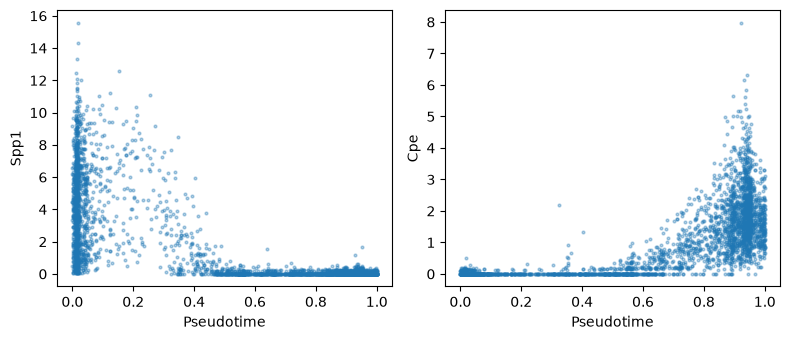

In [16]:
import matplotlib.pyplot as plt

cell_key = pseudotime.validity_key
ptime = ds.get_cell_vals(
    from_assay="RNA",
    cell_key=cell_key,
    k=pseudotime.pseudotime_key,
)
figure, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True)
for axis, gene in zip(axes, checkpoint_genes, strict=True):
    expression = ds.get_cell_vals(
        from_assay="RNA",
        cell_key=cell_key,
        k=gene,
    )
    axis.scatter(ptime, expression, s=4, alpha=0.35)
    axis.set(xlabel="Pseudotime", ylabel=gene)
figure.tight_layout()
plt.show()